# Lab 1: Vector Addition

---

## Overview

This lab introduces the fundamental programming model for AMD GPUs using HIP. You will learn how software abstractions (grids, blocks, threads) map to the underlying hardware (Compute Units, SIMDs, Wavefronts).

## Learning Objectives

By the end of this lab, you will be able to:

1. Describe the hierarchical thread organization in GPU programming
2. Explain how threads map to AMD GPU hardware components
3. Calculate global thread indices for kernel execution
4. Analyze the impact of block size on thread utilization and occupancy

## 1. The GPU Execution Model

GPU programming follows a **Single Instruction, Multiple Thread (SIMT)** model. A single kernel function is executed by thousands of threads simultaneously, each operating on different data.

### Hierarchical Thread Organization

Threads are organized into a three-level hierarchy:

```
Grid (Kernel Launch)
 |
 +-- Block 0
 |    +-- Thread 0, Thread 1, ..., Thread (blockDim-1)
 +-- Block 1
 |    +-- Thread 0, Thread 1, ..., Thread (blockDim-1)
 +-- ...
 +-- Block (gridDim-1)
      +-- Thread 0, Thread 1, ..., Thread (blockDim-1)
```

### Key Terminology

| Term | Definition |
|:-----|:-----------|
| **Kernel** | A function that executes on the GPU, launched from the host (CPU) |
| **Grid** | The complete set of threads executing a kernel |
| **Block** | A group of threads that can cooperate via shared memory and synchronization |
| **Thread** | The smallest unit of execution; each thread has a unique ID |
| **gridDim** | Number of blocks in the grid |
| **blockDim** | Number of threads per block |
| **blockIdx** | Index of the current block within the grid |
| **threadIdx** | Index of the current thread within its block |

## 2. AMD GPU Hardware Architecture

Understanding the hardware is essential for writing efficient GPU code. The programming model abstractions map directly to physical hardware components.

### Architecture Families

AMD has two GPU architecture families:

| Architecture | Target | Native Wavefront | Supported Modes | Example GPUs |
|:-------------|:-------|:-----------------|:-----------------|:-------------|
| **CDNA** | Data center / HPC | 64 threads | wave64 only | MI100, MI210, MI300X |
| **RDNA 3/3.5** | Consumer / Mobile | **32 threads** | **wave32 + wave64** | Radeon RX 7000, Radeon 8060S |

### Wave32 vs Wave64 on RDNA 3.5

RDNA 3.5 **supports both** wave32 and wave64, but is **natively optimized for wave32**:

| | Wave32 (default) | Wave64 |
|:--|:-----------------|:-------|
| Execution | 1 pass per vector instruction | 2 passes (low 32 + high 32 lanes) |
| Branch divergence cost | Lower | Higher |
| Scheduler pressure | Lower | Lower (fewer waves to track) |
| HIP default on RDNA | **Yes** | Need explicit `-mwavefrontsize64` |

> **Key Point**: A compiled kernel runs at **one fixed wave size**. On RDNA 3.5, `hipcc` defaults to **wave32** unless you explicitly pass `-mwavefrontsize64`.

### How to Check Your Actual Wavefront Size

```bash
# Method 1: rocminfo reports the hardware native wavefront size
rocminfo | grep -i "Wavefront Size"

# Method 2: Check what hipcc compiles to (shows in program output)
# Our vector_add_lab prints "Warp Size" from hipDeviceGetAttribute()
```

### Hardware Components

| Software Abstraction | AMD Hardware | Role |
|:---------------------|:-------------|:-----|
| Grid | GPU Device | Entire kernel workload |
| Block | Compute Unit (CU) / WGP | Independent execution unit |
| Warp (Wavefront) | SIMD Unit | 32 or 64 threads executing in lockstep |
| Thread | Vector Lane | Single execution context |

### RDNA 3.5 Workgroup Processor (WGP)

On RDNA 3.5, the basic execution unit is the **Workgroup Processor (WGP)**, which contains:

| Component | Description |
|:----------|:------------|
| **2 Compute Units** | Each CU has its own SIMD units |
| **4 SIMD32 Units** | Each processes 32 lanes per cycle |
| **Vector Register File** | Private registers for each thread |
| **Local Data Share (LDS)** | Shared memory within a WGP |
| **Scalar Unit** | Handles uniform operations across a wavefront |

### Wavefront (Warp) Execution

On RDNA 3.5 with default wave32:

- All 32 threads execute the same instruction simultaneously on one SIMD32 unit
- All threads in a wavefront must execute the same instruction (SIMT)
- If threads diverge (take different branches), both paths are executed serially
- Wave64 mode splits each vector instruction into 2 passes of 32 lanes

**Important**: On this platform (default wave32), block sizes should be multiples of **32** to avoid wasting execution resources.

## 3. Thread Indexing

Each thread must determine which data element it should process. This is done by computing a **global thread index**.

### 1D Indexing Formula

For a 1D grid with 1D blocks:

$$
\text{globalIdx} = \text{blockIdx.x} \times \text{blockDim.x} + \text{threadIdx.x}
$$

### Visual Example

Consider a grid with 3 blocks, each containing 4 threads:

```
Block 0              Block 1              Block 2
+---+---+---+---+    +---+---+---+---+    +---+---+---+---+
| 0 | 1 | 2 | 3 |    | 4 | 5 | 6 | 7 |    | 8 | 9 |10 |11 |  <- Global Index
+---+---+---+---+    +---+---+---+---+    +---+---+---+---+
  0   1   2   3        0   1   2   3        0   1   2   3    <- threadIdx.x
  blockIdx.x = 0       blockIdx.x = 1       blockIdx.x = 2
```

**Example Calculation** (Thread 5):
- `blockIdx.x = 1`, `blockDim.x = 4`, `threadIdx.x = 1`
- `globalIdx = 1 * 4 + 1 = 5`

### Exercise: Thread Index Calculation

Fill in the global index for each thread:

| blockIdx.x | blockDim.x | threadIdx.x | Global Index |
|:-----------|:-----------|:------------|:-------------|
| 0 | 256 | 100 | ______ |
| 2 | 128 | 50 | ______ |
| 5 | 64 | 0 | ______ |

### Answers

- `0 * 256 + 100 = 100`
- `2 * 128 + 50 = 306`
- `5 * 64 + 0 = 320`


## 4. Exploring Your GPU

Before writing kernels, examine the hardware specifications of your GPU.

In [2]:
%%bash
# Query GPU device properties
echo "=== Device Info ==="
rocminfo 2>/dev/null | grep -E "Marketing Name|Compute Unit|Wavefront Size" | head -6
echo ""
echo "=== HIP Device Properties ==="
hipinfo 2>/dev/null | head -20 || echo "(hipinfo not available, use rocminfo output above)"
echo ""
echo "Note: RDNA 3.5 supports both wave32 and wave64."
echo "      hipcc defaults to wave32 on RDNA. Check 'Wavefront Size' above."

=== Device Info ===
  Marketing Name:          AMD Ryzen AI 9 HX 370 w/ Radeon 890M
  Compute Unit:            24                                 
  Marketing Name:          AMD Radeon 890M Graphics           
  Compute Unit:            16                                 
  Wavefront Size:          32(0x20)                           

=== HIP Device Properties ===

Note: RDNA 3.5 supports both wave32 and wave64.
      hipcc defaults to wave32 on RDNA. Check 'Wavefront Size' above.


### Exercise 1: GPU Specifications

Based on the output above, record your GPU's specifications:

| Property | Your GPU Value | Significance |
|:---------|:---------------|:-------------|
| Device Name | ______ | GPU model identifier |
| Compute Units | ______ | Number of parallel execution units |
| Wavefront Size | ______ | Threads per warp (**32 on RDNA**, 64 on CDNA) |
| Max Threads per Block | ______ | Upper limit for blockDim |
| Max Shared Memory per Block | ______ | LDS available per block |

**Question**: How many total threads can your GPU execute simultaneously if all CUs are fully utilized?

Your calculation: ______

### Answers

| Property | Answer |
|:--|:--|
| Device Name | AMD Radeon 890M Graphics |
| Compute Units | 8 reported by HIP (`rocminfo` lists 16 CUs) |
| Wavefront Size | 32 |
| Max Threads per Block | 1024 |
| Max Shared Memory per Block | 64 KB / 65536 bytes |

`8 CUs * 64 wavefronts/CU * 32 threads/wavefront = 16384 threads`.


## 5. Your First HIP Kernel

We will implement a vector addition kernel: $C[i] = A[i] + B[i]$

This simple kernel demonstrates the basic structure of GPU programming:
1. Each thread processes one element
2. Threads compute their global index
3. Boundary checking prevents out-of-bounds access

### Kernel Structure

```cpp
__global__ void vector_add(const float* A, const float* B, float* C, int N) {
    // Step 1: Calculate global thread index
    int idx = _______________________________;  // Fill in
    
    // Step 2: Boundary check (important when N is not divisible by block size)
    if (______) {  // Fill in the condition
        // Step 3: Perform computation
        C[idx] = _______________________________;  // Fill in
    }
}
```

### Exercise 2: Implement the Kernel

Complete the kernel in `vector_add_kernel.hip` based on the structure above.

### Answers

```cpp
int idx = blockIdx.x * blockDim.x + threadIdx.x;
if (idx < N) {
    C[idx] = A[idx] + B[idx];
}
```

`vector_add_kernel.hip` has been completed with this indexing, boundary check, and vector-add expression.


In [3]:
# View the kernel file
with open('vector_add_kernel.hip', 'r') as f:
    print(f.read())

#include <hip/hip_runtime.h>

/**
 * Vector Addition Kernel
 * 
 * Each thread computes one element: C[i] = A[i] + B[i]
 * 
 * Thread Indexing:
 *   Global thread ID = blockIdx.x * blockDim.x + threadIdx.x
 * 
 * @param A     Input vector A
 * @param B     Input vector B  
 * @param C     Output vector C
 * @param N     Vector length
 */
__global__ void vector_add(const float* A, const float* B, float* C, int N) {
    // Calculate global thread index
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    
    // Boundary check
    if (idx < N) {
        C[idx] = A[idx] + B[idx];
    }
}



## 6. Compile the Program

In [5]:
%%bash
# Compile with hipcc
hipcc -O3 main_lab.cpp vector_add_kernel.hip -o vector_add_lab

## 7. Launch Configuration

When launching a kernel, you must specify the **grid** and **block** dimensions.

### Kernel Launch Syntax

```cpp
hipLaunchKernelGGL(kernel_name, 
                   dim3(grid_size),    // Number of blocks
                   dim3(block_size),   // Threads per block
                   shared_mem_size,    // Dynamic shared memory (bytes)
                   stream,             // HIP stream (0 for default)
                   arg1, arg2, ...);   // Kernel arguments
```

### Calculating Grid Size

To ensure all N elements are processed:

$$
\text{grid\_size} = \left\lceil \frac{N}{\text{block\_size}} \right\rceil = \frac{N + \text{block\_size} - 1}{\text{block\_size}}
$$

### Thread Utilization

When N is not divisible by block_size, some threads in the last block are idle:

$$
\text{Utilization} = \frac{N}{\text{grid\_size} \times \text{block\_size}} \times 100\%
$$

### Exercise 3: Launch Configuration Calculation

Given `N = 1000` elements, complete the table:

| Block Size | Grid Size Formula | Grid Size | Total Threads | Idle Threads |
|:-----------|:------------------|:----------|:--------------|:-------------|
| 64 | ceil(1000/64) | ______ | ______ | ______ |
| 128 | ceil(1000/128) | ______ | ______ | ______ |
| 256 | ceil(1000/256) | ______ | ______ | ______ |
| 512 | ceil(1000/512) | ______ | ______ | ______ |

**Question**: Which block size gives the best thread utilization? Why might this not always be the best choice?

Your answer: ______

### Answers

| Block Size | Grid Size | Total Threads | Idle Threads |
|:--|--:|--:|--:|
| 64 | 16 | 1024 | 24 |
| 128 | 8 | 1024 | 24 |
| 256 | 4 | 1024 | 24 |
| 512 | 2 | 1024 | 24 |

All four block sizes have the same thread utilization: `1000 / 1024 = 97.66%`. This may not always be the best choice because performance also depends on wavefront alignment, occupancy, register pressure, shared memory usage, and scheduling overhead.


In [6]:
# Verify your calculations
import math

N = 1000
block_sizes = [64, 128, 256, 512]

print(f"{'Block Size':>10} {'Grid Size':>10} {'Total Threads':>14} {'Idle Threads':>13} {'Utilization':>12}")
print("-" * 62)

for bs in block_sizes:
    grid_size = math.ceil(N / bs)
    total_threads = grid_size * bs
    idle_threads = total_threads - N
    utilization = (N / total_threads) * 100
    print(f"{bs:>10} {grid_size:>10} {total_threads:>14} {idle_threads:>13} {utilization:>11.2f}%")

Block Size  Grid Size  Total Threads  Idle Threads  Utilization
--------------------------------------------------------------
        64         16           1024            24       97.66%
       128          8           1024            24       97.66%
       256          4           1024            24       97.66%
       512          2           1024            24       97.66%


## 8. Confirm Your GPU & Run Multi-Trial Experiments

Before running performance experiments, we first confirm the GPU model and wavefront size, then run each block size **multiple times** to get reliable averages.

### Why Multiple Trials?

Single-run measurements on short kernels are noisy due to:
- GPU frequency scaling and thermal throttling
- OS/driver scheduling jitter
- Cache warm-up effects

We run each configuration **10 times** and report the **mean** and **standard deviation**.

In [7]:
%%bash
# Step 1: Confirm GPU model and actual wavefront size
echo "=== GPU Detection ==="
./vector_add_lab 1024 32 2>&1 | grep -E "Device:|Compute Units:|Warp Size:|Max Threads|Max Blocks"
echo ""
echo "=== Wavefront Size from rocminfo ==="
rocminfo 2>/dev/null | grep "Wavefront Size" | head -2
echo ""
echo "Reminder: RDNA 3.5 natively uses wave32 (hipcc default)."
echo "          wave64 requires explicit -mwavefrontsize64 flag."
echo "          Block sizes should be multiples of the active wavefront size."

=== GPU Detection ===
Device: AMD Radeon 890M Graphics
Compute Units: 8
Max Threads per Block: 1024
Warp Size: 32
Max Blocks per CU: 64

=== Wavefront Size from rocminfo ===
  Wavefront Size:          32(0x20)                           

Reminder: RDNA 3.5 natively uses wave32 (hipcc default).
          wave64 requires explicit -mwavefrontsize64 flag.
          Block sizes should be multiples of the active wavefront size.


In [8]:
%%bash
# Step 2: Multi-trial experiment across block sizes
# Run each block size 10 times and collect kernel execution times

N=1048576
TRIALS=10

echo "N=$N, Trials=$TRIALS"
echo "---"

for BS in 16 32 64 128 256 512 1024; do
    echo -n "BS=$BS: "
    for i in $(seq 1 $TRIALS); do
        ./vector_add_lab $N $BS 2>/dev/null | grep "Kernel execution time" | awk '{printf "%s ", $4}'
    done
    echo ""
done

N=1048576, Trials=10
---
BS=16: 0.139277 0.145756 0.151476 0.142076 0.165076 0.149075 0.150795 0.150235 0.139876 0.148676 
BS=32: 0.150516 0.152556 0.156075 0.149637 0.151076 0.159516 0.165076 0.149276 0.145516 0.134477 
BS=64: 0.142916 0.148196 0.126318 0.149917 0.147876 0.148957 0.152156 0.148756 0.151795 0.149556 
BS=128: 0.143717 0.168676 0.142477 0.154356 0.151917 0.151795 0.143434 0.149196 0.162196 0.153797 
BS=256: 0.161555 0.151076 0.139756 0.154753 0.150877 0.149997 0.141076 0.148677 0.139835 0.148677 
BS=512: 0.139797 0.155154 0.149077 0.154314 0.152515 0.147715 0.140796 0.151517 0.134075 0.148515 
BS=1024: 0.143916 0.146555 0.131758 0.147516 0.143877 0.143237 0.137197 0.160156 0.135954 0.152676 


Block Size  Mean (ms)   Std (ms)   Min (ms)   Max (ms)  Trials
------------------------------------------------------------
        16     0.1483     0.0057     0.1397     0.1571      10
        32     0.1464     0.0075     0.1302     0.1527      10
        64     0.1483     0.0052     0.1427     0.1602      10
       128     0.1462     0.0066     0.1367     0.1574      10
       256     0.1449     0.0093     0.1298     0.1534      10
       512     0.1412     0.0060     0.1344     0.1524      10
      1024     0.1424     0.0090     0.1263     0.1592      10


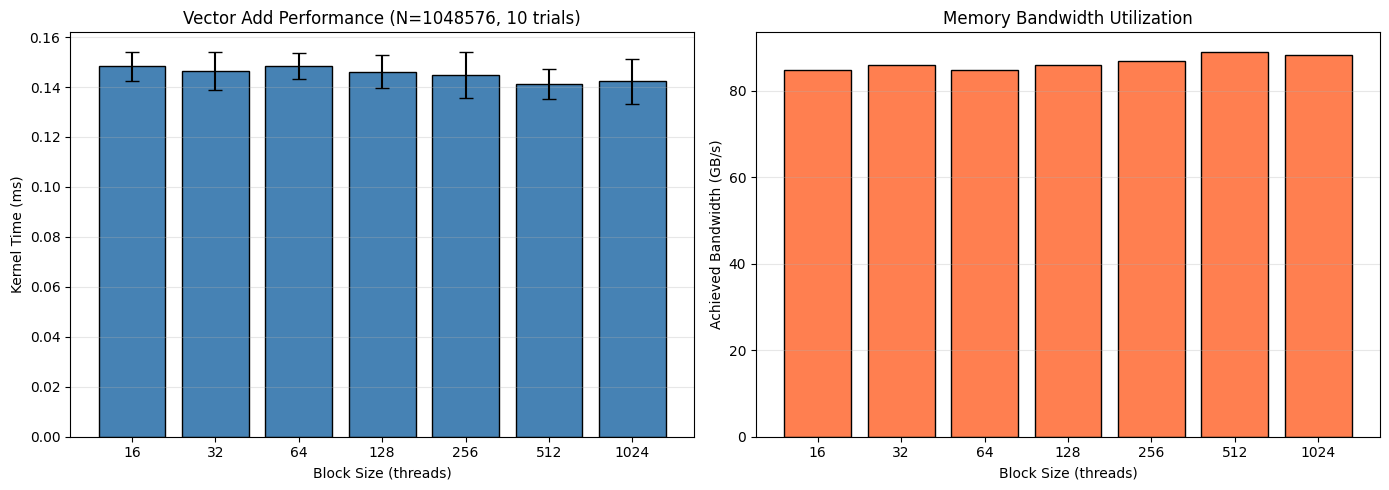


Plot saved to block_size_performance.png


In [9]:
import subprocess, re, statistics
import matplotlib.pyplot as plt

# Step 3: Parse multi-trial results and plot
N = 1048576
TRIALS = 10
block_sizes = [16, 32, 64, 128, 256, 512, 1024]

results = {}
for bs in block_sizes:
    times = []
    for _ in range(TRIALS):
        out = subprocess.run(
            ["./vector_add_lab", str(N), str(bs)],
            capture_output=True, text=True
        )
        m = re.search(r"Kernel execution time:\s+([\d.]+)\s+ms", out.stdout)
        if m:
            times.append(float(m.group(1)))
    if times:
        results[bs] = times

# Print summary table
print(f"{'Block Size':>10} {'Mean (ms)':>10} {'Std (ms)':>10} {'Min (ms)':>10} {'Max (ms)':>10} {'Trials':>7}")
print("-" * 60)
means = []
stds = []
for bs in block_sizes:
    t = results.get(bs, [])
    if t:
        m, s = statistics.mean(t), statistics.stdev(t) if len(t) > 1 else 0
        means.append(m)
        stds.append(s)
        print(f"{bs:>10} {m:>10.4f} {s:>10.4f} {min(t):>10.4f} {max(t):>10.4f} {len(t):>7}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart with error bars
x_labels = [str(bs) for bs in block_sizes]
ax1.bar(x_labels, means, yerr=stds, capsize=5, color='steelblue', edgecolor='black')
ax1.set_xlabel("Block Size (threads)")
ax1.set_ylabel("Kernel Time (ms)")
ax1.set_title(f"Vector Add Performance (N={N}, {TRIALS} trials)")
ax1.grid(axis='y', alpha=0.3)

# Achieved bandwidth
bytes_transferred = 12 * N  # 2 reads + 1 write, each 4 bytes
bw_gb_s = [(bytes_transferred / (m * 1e-3)) / 1e9 for m in means]
ax2.bar(x_labels, bw_gb_s, color='coral', edgecolor='black')
ax2.set_xlabel("Block Size (threads)")
ax2.set_ylabel("Achieved Bandwidth (GB/s)")
ax2.set_title("Memory Bandwidth Utilization")
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("block_size_performance.png", dpi=150)
plt.show()
print("\nPlot saved to block_size_performance.png")

### Exercise 4: Analyze Your Results

Based on the multi-trial results above:

1. Which block size achieved the **lowest mean execution time**? ______
2. Which block size achieved the **highest memory bandwidth**? ______
3. Are the differences between block sizes **statistically significant** (look at error bars)?  ______
4. Why does Vector Add performance depend more on bandwidth than on block size?

Your answer: ______

### Answers

1. Lowest mean execution time: 512 threads per block, mean time `0.1412 ms`.
2. Highest memory bandwidth: 512 threads per block, because bytes transferred are fixed and this block size had the lowest mean execution time.
3. Statistical significance: not strong; the means are close and the standard deviations overlap for most block sizes.

Vector addition is memory-bandwidth bound. Each element performs one floating-point addition but requires two global memory reads and one global memory write, so memory traffic dominates runtime.


## 9. Wavefront Alignment

On **RDNA 3.5** GPUs with default compilation (wave32), the wavefront size is **32 threads**. Block sizes that are not multiples of 32 result in partially filled wavefronts.

> **Dual-mode reminder**: RDNA 3.5 supports both wave32 and wave64. The alignment target depends on which mode your kernel is compiled with. Default `hipcc` on RDNA → **wave32**.
>
> **CDNA Note**: On CDNA GPUs (MI100/MI210), the wavefront size is always 64.

### Wavefront Occupancy by Block Size (Wave32 mode)

| Block Size | Wavefronts per Block | Wasted Lanes per Block |
|:-----------|:---------------------|:-----------------------|
| 16 | 1 (half empty) | 16 |
| 32 | 1 | 0 |
| 48 | 2 (one half empty) | 16 |
| 64 | 2 | 0 |
| 128 | 4 | 0 |
| 256 | 8 | 0 |

### Exercise 5: Wavefront Analysis

**Question 1**: A kernel is launched with block size 100. How many wavefronts does each block require? How many lanes are wasted?

- Wavefronts per block: ______ (hint: $\lceil 100/32 \rceil$)
- Wasted lanes: ______ (hint: wavefronts × 32 − 100)

**Question 2**: If the same kernel were compiled with `-mwavefrontsize64`, how would the answers change?

- Wavefronts per block (wave64): ______ (hint: $\lceil 100/64 \rceil$)
- Wasted lanes (wave64): ______

**Question 3**: What happens when threads within a wavefront take different branches (if-else)?

Your answer: ______

### Answers

- Wavefronts per block: 4, because `ceil(100 / 32) = 4`.
- Wasted lanes: 28, because `4 * 32 - 100 = 28`.
- Wavefronts per block in wave64: 2, because `ceil(100 / 64) = 2`.
- Wasted lanes in wave64: 28, because `2 * 64 - 100 = 28`.

When threads in the same wavefront take different branches, the GPU executes the branch paths serially using masks. This branch divergence reduces parallel efficiency and can lower performance.


## 10. Occupancy

**Occupancy** is the ratio of active warps to the maximum warps a CU can support. Higher occupancy can help hide memory latency.

### Factors Limiting Occupancy

| Resource | How It Limits Occupancy |
|:---------|:------------------------|
| **Registers per thread** | More registers = fewer threads can fit on CU |
| **Shared memory per block** | More LDS = fewer blocks can fit on CU |
| **Block size** | Hardware limits max blocks per CU |

### Exercise 6: Occupancy Calculation

**For Radeon 8060S (RDNA 3.5)**: 20 CUs, Warp Size = 32, Max Blocks per CU = 64, Max Threads per Block = 1024

To calculate occupancy, you need to know the max wavefronts per CU (check `rocminfo` output).

| Block Size | Wavefronts/Block | Blocks that fit | Active Wavefronts | Notes |
|:-----------|:-----------------|:----------------|:------------------|:------|
| 32 | 1 | limited by max blocks (64) | 64 | ______ |
| 64 | 2 | ______ | ______ | ______ |
| 128 | 4 | ______ | ______ | ______ |
| 256 | 8 | ______ | ______ | ______ |
| 512 | 16 | ______ | ______ | ______ |
| 1024 | 32 | ______ | ______ | ______ |

**Note**: Use `rocminfo` output from Exercise 1 to determine actual hardware limits for your device.

### Answers

| Block Size | Blocks that fit | Active Wavefronts | Notes |
|:--|--:|--:|:--|
| 32 | limited by max blocks (64) | 64 | reaches the 64 wavefront/CU cap |
| 64 | 32 | 64 | limited by max wavefronts per CU |
| 128 | 16 | 64 | limited by max wavefronts per CU |
| 256 | 8 | 64 | limited by max wavefronts per CU |
| 512 | 4 | 64 | limited by max wavefronts per CU |
| 1024 | 2 | 64 | limited by max wavefronts per CU |


## 11. Experiment: Effect of Sub-Wavefront Block Sizes

What happens when block size is **smaller** than the wavefront size?

On RDNA 3.5 (wave32), a sub-wavefront block size means **block size < 32** (e.g., 16, 8).
Each such block still occupies a full wavefront, wasting lanes.

Block Size  Mean (ms)   Std (ms)  Sub-Wave?
---------------------------------------------
         8     0.1943     0.0469        YES
        16     0.1467     0.0062        YES
        32     0.1480     0.0083         no
        64     0.1452     0.0128         no
       128     0.1467     0.0097         no
       256     0.1469     0.0105         no


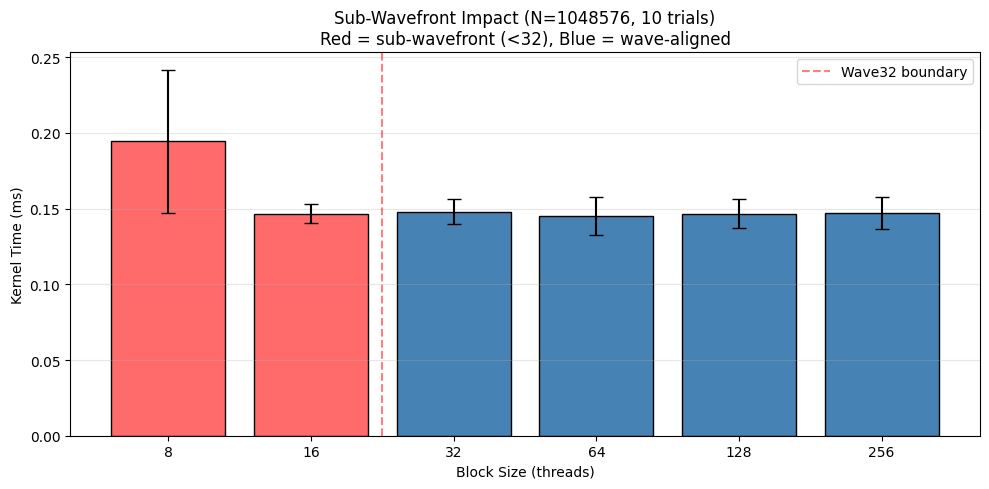


Plot saved to sub_wavefront_impact.png


In [10]:
import subprocess, re, statistics
import matplotlib.pyplot as plt

# Multi-trial sub-wavefront experiment
N = 1048576
TRIALS = 10
# Include sub-wave (8, 16), wave-aligned (32), and larger for comparison
block_sizes = [8, 16, 32, 64, 128, 256]

results = {}
for bs in block_sizes:
    times = []
    for _ in range(TRIALS):
        out = subprocess.run(
            ["./vector_add_lab", str(N), str(bs)],
            capture_output=True, text=True
        )
        m = re.search(r"Kernel execution time:\s+([\d.]+)\s+ms", out.stdout)
        if m:
            times.append(float(m.group(1)))
    if times:
        results[bs] = times

# Print summary
print(f"{'Block Size':>10} {'Mean (ms)':>10} {'Std (ms)':>10} {'Sub-Wave?':>10}")
print("-" * 45)
means, stds = [], []
for bs in block_sizes:
    t = results.get(bs, [])
    if t:
        m, s = statistics.mean(t), statistics.stdev(t) if len(t) > 1 else 0
        means.append(m)
        stds.append(s)
        sub = "YES" if bs < 32 else "no"
        print(f"{bs:>10} {m:>10.4f} {s:>10.4f} {sub:>10}")

# Plot: sub-wavefront impact
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#ff6b6b' if bs < 32 else 'steelblue' for bs in block_sizes]
bars = ax.bar([str(bs) for bs in block_sizes], means, yerr=stds, capsize=5,
              color=colors, edgecolor='black')

ax.axvline(x=1.5, color='red', linestyle='--', alpha=0.5, label='Wave32 boundary')
ax.set_xlabel("Block Size (threads)")
ax.set_ylabel("Kernel Time (ms)")
ax.set_title(f"Sub-Wavefront Impact (N={N}, {TRIALS} trials)\nRed = sub-wavefront (<32), Blue = wave-aligned")
ax.grid(axis='y', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("sub_wavefront_impact.png", dpi=150)
plt.show()
print("\nPlot saved to sub_wavefront_impact.png")

### Exercise 7: Analyze Sub-Wavefront Results

Based on the multi-trial results above:

- Mean time for block size 8 (sub-wave): ______ ms
- Mean time for block size 16 (sub-wave): ______ ms
- Mean time for block size 32 (wave-aligned): ______ ms
- Mean time for block size 256 (large): ______ ms

**Question 1**: Is there a noticeable performance penalty for sub-wavefront block sizes (8, 16) compared to wave-aligned sizes (32, 64, 128)?

Your answer: ______

**Question 2**: On this RDNA 3.5 GPU, the wavefront size is 32. If you were on an MI100 (wavefront = 64), which block sizes would become sub-wavefront?

Your answer: ______

### Answers

- Block size 8 mean time: `0.1943 ms`.
- Block size 16 mean time: `0.1467 ms`.
- Block size 32 mean time: `0.1480 ms`.
- Block size 256 mean time: `0.1469 ms`.

Block size 8 shows a noticeable penalty because it uses only part of a wavefront while still occupying wavefront resources. Block size 16 is close to wave-aligned sizes in this measurement, so its penalty is not clearly significant here.

On MI100, wavefront size is 64, so block sizes smaller than 64 would become sub-wavefront: 8, 16, and 32.


## 12. Summary

### Key Takeaways

1. **Thread Hierarchy**: GPU threads are organized into Grids, Blocks, and Threads

2. **Hardware Mapping**: Blocks map to Compute Units / WGPs; Wavefronts execute on SIMDs
   - **RDNA 3.5** (this lab): wavefront = **32 threads** (wave32)
   - **CDNA** (MI100/MI210): wavefront = 64 threads (wave64)

3. **Block Size Selection**:
   - Should be a multiple of wavefront size (**32 on RDNA**, 64 on CDNA)
   - Common choices: 128, 256, or 512
   - Tradeoff between occupancy and register/shared memory pressure

4. **Thread Utilization**: Not all launched threads may do useful work when N is not divisible by block size

5. **Measurement Methodology**: Always run multiple trials and report mean ± std to get reliable results

### Best Practices

| Guideline | Reason |
|:----------|:-------|
| Block size = multiple of wavefront size | Avoid partial wavefront waste |
| Block size between 128-512 | Balance occupancy and resource usage |
| Start with 256 threads per block | Good default for most kernels |
| Run multiple trials | Reduce measurement noise |
| Check your GPU first (`rocminfo`) | Know your wavefront size! |

## 13. Challenge Exercise

Modify the kernel to process **multiple elements per thread**. This is a common technique when N is very large.

```cpp
__global__ void vector_add_multi(const float* A, const float* B, float* C, 
                                  int N, int elements_per_thread) {
    int tid = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = _______________________________;  // Fill in: total number of threads
    
    for (int i = tid; i < N; i += stride) {
        C[i] = A[i] + B[i];
    }
}
```

**Question**: What is the advantage of this approach over the 1:1 thread-to-element mapping?

### Answers

```cpp
int stride = gridDim.x * blockDim.x;
```

The grid-stride loop allows a fixed number of launched threads to process arrays larger than the total number of threads. This makes the kernel more flexible and scalable, and avoids requiring an extremely large grid for very large input sizes.


---

## Appendix: Reference Files

- `vector_add_kernel.hip` - Kernel implementation (student version)
- `vector_add_reference.hip` - Reference solution with annotations
- `main_lab.cpp` - Main program with timing and verification